Purpose: To explore the Bhutan basin boundary from the Bhutan NSDI System website.

Install libraries </bt>
- here on the notebook or 
- from terminal within a python virtual environment<br/>

For Notebook option <br/>
 ```
 !pip install --upgrade pip
 !pip install -r requirements.txt
 ``` 
<br/>

For terminal option <br/>
open up a new terminal for instance in a VSCode environment
```
> python -m venv bb_venv <br/>
> bb_venv\Scripts\activate.bat <br/>
(bb_venv)> python -m pip install --upgrade pip  <br/>
(bb_venv)> pip install -r requirements.txt <br/>
```
<br/>


**NOTE:First time run, you need to choose the python environment and it might install ipykernel as well**

In [ ]:
!pip install --upgrade pip
!pip install -r requirements.txt

**Import Libraries**

In [1]:
import os
import pandas as pd
import yaml

import fiona
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt 

import json
import re
from functools import reduce

from pyproj import CRS


needs the following libraries installed
- cfgrib
- xarray
- eccodes
- shapely 
- fiona
- geopandas
- pyproj
- rtree

- PyYaml

NOTE: for now we aren't yet using climatesense.yaml - something to think about



In [ ]:
cwd = os.getcwd()
cwd


**Set up base path for data**

In [2]:
def get_base_data_path(src="", path_suffix=""):
    config_data = None
    base_data_dir = ""
    if src == "":
        base_data_dir = f"../../data{path_suffix}"
    else:
        print("yaml - config settings not in use yet...")
        # # Load the .yaml file to load all the cofiguration settings for the app
        # # like base data path and any other common information needed all through the Climatesense app
        # with open('climatesense.yaml', 'r') as f:
        #     config_data = yaml.safe_load(f)

        # base_data_dir = base_data_dir['data_dir']['base_dir']

    return base_data_dir

##### **Explore Bhutan Basin data**

**Set basin data paths**

In [3]:
base_data_path = get_base_data_path()
base_data_path

'../../data'

In [4]:
watershed_boundary_data_path = get_base_data_path(path_suffix="/boundaries/186_watershed")
watershed_boundary_data_path

'../../data/boundaries/186_watershed'

**Inpect .prj file of Basin boundary, to check the CRS used, if present**

In [5]:
boun_prj_file = f"{watershed_boundary_data_path}/186 Watershed boundary.prj"

In [6]:
with open(boun_prj_file, "r") as prj_file:
    prj_text = prj_file.read()

In [7]:
# check if prj_text holds the content of 'Bhutan boundary.prj' file
crs = CRS(prj_text)
epsg = crs.to_epsg()
print(f"Name: {crs.name}")
print(f"Coordinate system: {crs.coordinate_system}")
print(f"Area of Use: {crs.area_of_use}")
print(f"EPSG Code (if available): {epsg}")

Name: WGS 84 / Pseudo-Mercator
Coordinate system: cartesian
Area of Use: None
EPSG Code (if available): 3857


**Load the previously downloaded Bhutan - basin boundary data as a .shp file**

In [8]:
boun_shp_file = f"{watershed_boundary_data_path}/186 Watershed boundary.shp"

In [10]:
def load_watershed_data(shp_file="", prj_crs=None):
    gdf_orig = None
    df_gdf_watershed_wgs84 = None
    # NOTE: features are the rows from the shp file
    # Refer: https://gis.stackexchange.com/questions/448450/getting-the-number-of-features-in-shapefile-without-opening-it-using-python
    #
    # If we have arcgis account then we can use, similar to below link...
    # Refer: https://gis.stackexchange.com/questions/381120/convert-arcgis-spatially-enabled-dataframe-to-geopandas-geodataframe

    # load shp file
    with fiona.open(shp_file) as features:
        print(f"Total features in basin boundary .shp file: {len(features)}")

        gdf_orig = gpd.GeoDataFrame.from_features(features)
        print(f"Loaded geoDataFrame shape: {gdf_orig.shape}")
        print(f"crs: {gdf_orig.crs}")
    # print(gdf_orig.head(2))

    # Set the correct CRS from the .prj file (Web Mercator)
    gdf_orig.set_crs(epsg=prj_crs, inplace=True)

    # Reproject to WGS84 (EPSG:4326)
    df_gdf_watershed_wgs84 = gdf_orig.to_crs("EPSG:4326")

    # Calculate centroids in WGS84
    centroids = df_gdf_watershed_wgs84.geometry.centroid

    # Extract longitude and latitude
    df_gdf_watershed_wgs84['longitude'] = centroids.x
    df_gdf_watershed_wgs84['latitude'] = centroids.y

    # Print the range
    print(f"Longitude range: {df_gdf_watershed_wgs84['longitude'].min()} to {df_gdf_watershed_wgs84['longitude'].max()}")
    print(f"Latitude range: {df_gdf_watershed_wgs84['latitude'].min()} to {df_gdf_watershed_wgs84['latitude'].max()}")
    # print(df_gdf_watershed_wgs84[['basin', 'longitude', 'latitude']].head())
    return df_gdf_watershed_wgs84


In [11]:
# load basin boundary data
gdf_watershed_wgs84 = load_watershed_data(shp_file=boun_shp_file, prj_crs=epsg)
gdf_watershed_wgs84.head(2)

Total features in basin boundary .shp file: 186
Loaded geoDataFrame shape: (186, 7)
crs: None
Longitude range: 88.88744181061193 to 92.03911802358823
Latitude range: 26.739830166575217 to 28.149654478026033


C:\Users\Pankaja\AppData\Local\Temp\ipykernel_412\2047485055.py:26: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = df_gdf_watershed_wgs84.geometry.centroid


,geometry,f_area,ws_id,area_ha,area_ha_1,SHAPE__Len,SHAPE__Are,longitude,latitude
0,"POLYGON ((92.04047 27.25524, 92.03816 27.25527...",1.403314e+08,1,14033.1356069597,14033.135607,88962.631299,1.783218e+08,92.034245,27.328438
1,"POLYGON ((89.74885 28.1869, 89.74993 28.18672,...",1.069433e+08,2,10694.331035308,10694.331035,72762.793824,1.380322e+08,89.693993,28.133971


**Visualize the geoDataFrame**

In [12]:
# just check the crs before visualizing to make sure it is WGS84
gdf_watershed_wgs84.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [13]:
def plot_watershed_boundaries(gdf=None, plt_title="", column=""):
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))

    # Plot the basin polygons (not points)
    # gdf.plot(ax=ax, column='basin', cmap='viridis', edgecolor='black', legend=True)
    gdf.plot(ax=ax, column=column, cmap='viridis', edgecolor='black')

    # Add basin name labels at centroid positions
    for idx, row in gdf.iterrows():
        ax.text(row['longitude'], row['latitude'], row[column],
                horizontalalignment='center', verticalalignment='center',
                fontsize=5, color='white', weight='bold',
                bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=1))

    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    plt.title(plt_title, fontsize=10)

    # Set axis limits to the extent of your data
    ax.set_xlim(gdf['longitude'].min()-0.35, gdf['longitude'].max()+0.7)
    ax.set_ylim(gdf['latitude'].min()-0.35, gdf['latitude'].max()+0.85)

    plt.show()



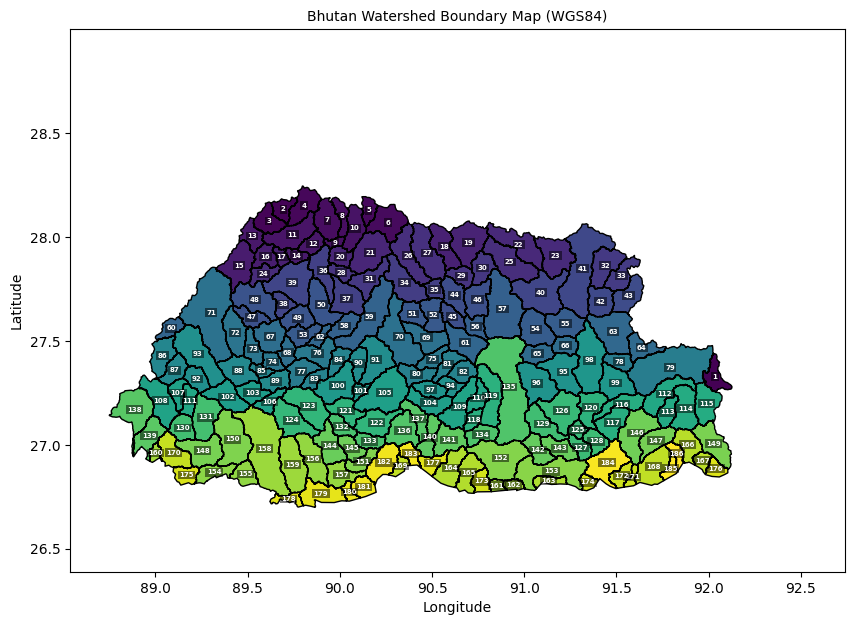

In [14]:
# plot basin-boundaries
plot_watershed_boundaries(gdf=gdf_watershed_wgs84, plt_title="Bhutan Watershed Boundary Map (WGS84)",
                          column="ws_id")


##### **Watershed stats**

In [15]:
gdf_watershed_wgs84.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [27]:
# derive some of the stat columns
geom = gdf_watershed_wgs84.geometry.to_crs(epsg=4326)
gdf_watershed_wgs84['area_sq_m'] = geom.area
gdf_watershed_wgs84['area_sq_km'] = geom.area / 10**6
gdf_watershed_wgs84["perimeter_m"] = geom.length


C:\Users\Pankaja\AppData\Local\Temp\ipykernel_412\2946608502.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_watershed_wgs84['area_sq_m'] = geom.area
C:\Users\Pankaja\AppData\Local\Temp\ipykernel_412\2946608502.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_watershed_wgs84['area_sq_km'] = geom.area / 10**6
C:\Users\Pankaja\AppData\Local\Temp\ipykernel_412\2946608502.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_watershed_wgs84["perimeter_m"] = geom.length


In [28]:
# Summary statistics
summary = {
    "Total watersheds": len(gdf_watershed_wgs84),
    "Total area (km²)": gdf_watershed_wgs84["area_sq_km"].sum(),
    "Average area (km²)": gdf_watershed_wgs84["area_sq_km"].mean(),
    "Min area (km²)": gdf_watershed_wgs84["area_sq_km"].min(),
    "Max area (km²)": gdf_watershed_wgs84["area_sq_km"].max(),
    "Average perimeter (km)": (gdf_watershed_wgs84["perimeter_m"].mean() / 1000),
    "Min perimeter (km)": (gdf_watershed_wgs84["perimeter_m"].min() / 1000),
    "Max perimeter (km)": (gdf_watershed_wgs84["perimeter_m"].max() / 1000),
}
for k, v in summary.items():
    print(f"{k}: {v:.2f}")

Total watersheds: 186.00
Total area (km²): 0.00
Average area (km²): 0.00
Min area (km²): 0.00
Max area (km²): 0.00
Average perimeter (km): 0.00
Min perimeter (km): 0.00
Max perimeter (km): 0.00


In [29]:
gdf_watershed_wgs84.columns

Index(['geometry', 'f_area', 'ws_id', 'area_ha', 'area_ha_1', 'SHAPE__Len',
       'SHAPE__Are', 'longitude', 'latitude', 'area_sq_m', 'area_sq_km',
       'perimeter_m'],
      dtype='object')

In [32]:
gdf_watershed_wgs84.shape

(186, 12)

##### **Explore towards final output - TBD**

**Output version - final_output_v1**

**Select few columns for now, we can improve upon as per the need**

**Save results as basin-discharge stats - in the ../../data/boundaries/processed folder**

**NOTE**: For now the processed file from super-imposing basin boundaries with discharge station - mean flow 
- is stored in the folder "../../data/boundaries/processed"

In [ ]:
# save_data_path = get_base_data_path(path_suffix="/boundaries/processed")
# save_data_path

In [ ]:
# # save final_output_v1 for now in the data folder itself
# def save_file(df, file_path="", version=""):
#     save_file = f"{file_path}_{version}.csv"
#     df.to_csv(save_file, index=None)

In [ ]:
# # make the folder and save
# os.makedirs(save_data_path, exist_ok=True, mode=0o777)
# results_file = f"{save_data_path}/basin_discharge_stats"
# version = "v1"
# save_file(df_final_output_v1, file_path=results_file, version=version)